[*********************100%***********************]  1 of 1 completed
D:\anaconda3\envs\COS30018\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - loss: 0.0805
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0118
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - loss: 0.0078
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - loss: 0.0070
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.0077
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - loss: 0.0067
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - loss: 0.0063
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - loss: 0.0072
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 0.0076
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - loss: 0.0070
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - loss: 0.0063
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.0057
Epoch 13/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - loss: 0.0059
Epoch 14/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - loss: 0.0059
Epoch 15/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - lo

[*********************100%***********************]  1 of 1 completed


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


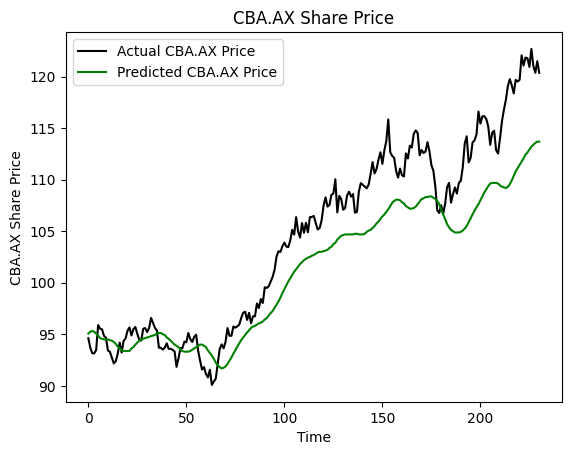

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction: [[113.7]]


In [1]:
# File: stock_prediction.py
# Authors: Bao Vo and Cheong Koo
# Date: 14/07/2021(v1); 19/07/2021 (v2); 02/07/2024 (v3)

# Code modified from:
# Title: Predicting Stock Prices with Python
# Youtuble link: https://www.youtube.com/watch?v=PuZY9q-aKLw
# By: NeuralNine

# Need to install the following (best in a virtual env):
# pip install numpy
# pip install matplotlib
# pip install pandas
# pip install tensorflow
# pip install scikit-learn
# pip install pandas-datareader
# pip install yfinance

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt
import tensorflow as tf
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, InputLayer

#------------------------------------------------------------------------------
# Load Data
## TO DO:
# 1) Check if data has been saved before. 
# If so, load the saved data
# If not, save the data into a directory
#------------------------------------------------------------------------------
# DATA_SOURCE = "yahoo"
COMPANY = 'CBA.AX'

TRAIN_START = '2020-01-01'     # Start date to read
TRAIN_END = '2023-08-01'       # End date to read

# data = web.DataReader(COMPANY, DATA_SOURCE, TRAIN_START, TRAIN_END) # Read data using yahoo


import yfinance as yf

# Get the data for the stock AAPL
data = yf.download(COMPANY,TRAIN_START,TRAIN_END)

#------------------------------------------------------------------------------
# Prepare Data
## To do:
# 1) Check if data has been prepared before. 
# If so, load the saved data
# If not, save the data into a directory
# 2) Use a different price value eg. mid-point of Open & Close
# 3) Change the Prediction days
#------------------------------------------------------------------------------
PRICE_VALUE = "Close"

scaler = MinMaxScaler(feature_range=(0, 1)) 
# Note that, by default, feature_range=(0, 1). Thus, if you want a different 
# feature_range (min,max) then you'll need to specify it here
scaled_data = scaler.fit_transform(data[PRICE_VALUE].values.reshape(-1, 1)) 
# Flatten and normalise the data
# First, we reshape a 1D array(n) to 2D array(n,1)
# We have to do that because sklearn.preprocessing.fit_transform()
# requires a 2D array
# Here n == len(scaled_data)
# Then, we scale the whole array to the range (0,1)
# The parameter -1 allows (np.)reshape to figure out the array size n automatically 
# values.reshape(-1, 1) 
# https://stackoverflow.com/questions/18691084/what-does-1-mean-in-numpy-reshape'
# When reshaping an array, the new shape must contain the same number of elements 
# as the old shape, meaning the products of the two shapes' dimensions must be equal. 
# When using a -1, the dimension corresponding to the -1 will be the product of 
# the dimensions of the original array divided by the product of the dimensions 
# given to reshape so as to maintain the same number of elements.

# Number of days to look back to base the prediction
PREDICTION_DAYS = 60 # Original

# To store the training data
x_train = []
y_train = []

scaled_data = scaled_data[:,0] # Turn the 2D array back to a 1D array
# Prepare the data
for x in range(PREDICTION_DAYS, len(scaled_data)):
    x_train.append(scaled_data[x-PREDICTION_DAYS:x])
    y_train.append(scaled_data[x])

# Convert them into an array
x_train, y_train = np.array(x_train), np.array(y_train)
# Now, x_train is a 2D array(p,q) where p = len(scaled_data) - PREDICTION_DAYS
# and q = PREDICTION_DAYS; while y_train is a 1D array(p)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# We now reshape x_train into a 3D array(p, q, 1); Note that x_train 
# is an array of p inputs with each input being a 2D array 

#------------------------------------------------------------------------------
# Build the Model
## TO DO:
# 1) Check if data has been built before. 
# If so, load the saved data
# If not, save the data into a directory
# 2) Change the model to increase accuracy?
#------------------------------------------------------------------------------
model = Sequential() # Basic neural network
# See: https://www.tensorflow.org/api_docs/python/tf/keras/Sequential
# for some useful examples

model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
# This is our first hidden layer which also spcifies an input layer. 
# That's why we specify the input shape for this layer; 
# i.e. the format of each training example
# The above would be equivalent to the following two lines of code:
# model.add(InputLayer(input_shape=(x_train.shape[1], 1)))
# model.add(LSTM(units=50, return_sequences=True))
# For som eadvances explanation of return_sequences:
# https://machinelearningmastery.com/return-sequences-and-return-states-for-lstms-in-keras/
# https://www.dlology.com/blog/how-to-use-return_state-or-return_sequences-in-keras/
# As explained there, for a stacked LSTM, you must set return_sequences=True 
# when stacking LSTM layers so that the next LSTM layer has a 
# three-dimensional sequence input. 

# Finally, units specifies the number of nodes in this layer.
# This is one of the parameters you want to play with to see what number
# of units will give you better prediction quality (for your problem)

model.add(Dropout(0.2))
# The Dropout layer randomly sets input units to 0 with a frequency of 
# rate (= 0.2 above) at each step during training time, which helps 
# prevent overfitting (one of the major problems of ML). 

model.add(LSTM(units=50, return_sequences=True))
# More on Stacked LSTM:
# https://machinelearningmastery.com/stacked-long-short-term-memory-networks/

model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1)) 
# Prediction of the next closing value of the stock price

# We compile the model by specify the parameters for the model
# See lecture Week 6 (COS30018)
model.compile(optimizer='adam', loss='mean_squared_error')
# The optimizer and loss are two important parameters when building an 
# ANN model. Choosing a different optimizer/loss can affect the prediction
# quality significantly. You should try other settings to learn; e.g.
    
# optimizer='rmsprop'/'sgd'/'adadelta'/...
# loss='mean_absolute_error'/'huber_loss'/'cosine_similarity'/...

# Now we are going to train this model with our training data 
# (x_train, y_train)
model.fit(x_train, y_train, epochs=30, batch_size=32)
# Other parameters to consider: How many rounds(epochs) are we going to 
# train our model? Typically, the more the better, but be careful about
# overfitting!
# What about batch_size? Well, again, please refer to 
# Lecture Week 6 (COS30018): If you update your model for each and every 
# input sample, then there are potentially 2 issues: 1. If you training 
# data is very big (billions of input samples) then it will take VERY long;
# 2. Each and every input can immediately makes changes to your model
# (a souce of overfitting). Thus, we do this in batches: We'll look at
# the aggreated errors/losses from a batch of, say, 32 input samples
# and update our model based on this aggregated loss.

# TO DO:
# Save the model and reload it
# Sometimes, it takes a lot of effort to train your model (again, look at
# a training data with billions of input samples). Thus, after spending so 
# much computing power to train your model, you may want to save it so that
# in the future, when you want to make the prediction, you only need to load
# your pre-trained model and run it on the new input for which the prediction
# need to be made.

#------------------------------------------------------------------------------
# Test the model accuracy on existing data
#------------------------------------------------------------------------------
# Load the test data
TEST_START = '2023-08-02'
TEST_END = '2024-07-02'

# test_data = web.DataReader(COMPANY, DATA_SOURCE, TEST_START, TEST_END)

test_data = yf.download(COMPANY,TEST_START,TEST_END)


# The above bug is the reason for the following line of code
# test_data = test_data[1:]

actual_prices = test_data[PRICE_VALUE].values

total_dataset = pd.concat((data[PRICE_VALUE], test_data[PRICE_VALUE]), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - PREDICTION_DAYS:].values
# We need to do the above because to predict the closing price of the fisrt
# PREDICTION_DAYS of the test period [TEST_START, TEST_END], we'll need the 
# data from the training period

model_inputs = model_inputs.reshape(-1, 1)
# TO DO: Explain the above line

model_inputs = scaler.transform(model_inputs)
# We again normalize our closing price data to fit them into the range (0,1)
# using the same scaler used above 
# However, there may be a problem: scaler was computed on the basis of
# the Max/Min of the stock price for the period [TRAIN_START, TRAIN_END],
# but there may be a lower/higher price during the test period 
# [TEST_START, TEST_END]. That can lead to out-of-bound values (negative and
# greater than one)
# We'll call this ISSUE #2

# TO DO: Generally, there is a better way to process the data so that we 
# can use part of it for training and the rest for testing. You need to 
# implement such a way

#------------------------------------------------------------------------------
# Make predictions on test data
#------------------------------------------------------------------------------
x_test = []
for x in range(PREDICTION_DAYS, len(model_inputs)):
    x_test.append(model_inputs[x - PREDICTION_DAYS:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
# TO DO: Explain the above 5 lines

predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)
# Clearly, as we transform our data into the normalized range (0,1),
# we now need to reverse this transformation 
#------------------------------------------------------------------------------
# Plot the test predictions
## To do:
# 1) Candle stick charts
# 2) Chart showing High & Lows of the day
# 3) Show chart of next few days (predicted)
#------------------------------------------------------------------------------

plt.plot(actual_prices, color="black", label=f"Actual {COMPANY} Price")
plt.plot(predicted_prices, color="green", label=f"Predicted {COMPANY} Price")
plt.title(f"{COMPANY} Share Price")
plt.xlabel("Time")
plt.ylabel(f"{COMPANY} Share Price")
plt.legend()
plt.show()

#------------------------------------------------------------------------------
# Predict next day
#------------------------------------------------------------------------------


real_data = [model_inputs[len(model_inputs) - PREDICTION_DAYS:, 0]]
real_data = np.array(real_data)
real_data = np.reshape(real_data, (real_data.shape[0], real_data.shape[1], 1))

prediction = model.predict(real_data)
prediction = scaler.inverse_transform(prediction)
print(f"Prediction: {prediction}")

# A few concluding remarks here:
# 1. The predictor is quite bad, especially if you look at the next day 
# prediction, it missed the actual price by about 10%-13%
# Can you find the reason?
# 2. The code base at
# https://github.com/x4nth055/pythoncode-tutorials/tree/master/machine-learning/stock-prediction
# gives a much better prediction. Even though on the surface, it didn't seem 
# to be a big difference (both use Stacked LSTM)
# Again, can you explain it?
# A more advanced and quite different technique use CNN to analyse the images
# of the stock price changes to detect some patterns with the trend of
# the stock price:
# https://github.com/jason887/Using-Deep-Learning-Neural-Networks-and-Candlestick-Chart-Representation-to-Predict-Stock-Market
# Can you combine these different techniques for a better prediction??